# Joint Diffusion training

In [6]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('diffusionsim')))
from tqdm import tqdm
from pathlib import Path
import json
import numpy as np
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim import mydatasets as data
from diffusionsim import climsim_utils as cut
import torch
from typing import Optional
from dataclasses import dataclass, asdict, field
from typing_extensions import Annotated
from pprint import pprint
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [7]:

def define_configs(exp_id, climsim_training=True, in_notebook=True, data_vars='v2', lr=1e-4):
    dl_params = tru.TrainLoaderParams()
    dl_params.batch_size = 32
    if(climsim_training):
        dl_params.batch_size *= 384
    dl_params.shuffle = True
    dl_params.pin_memory = True
    if(not in_notebook):
        dl_params.num_workers = 4
        dl_params.prefetch_factor = 3
        dl_params.persistent_workers = True
        dl_params.multiprocessing_context = "forkserver"
    
    dconfig = tru.DataConfig()
    if True:
        dconfig.dataloader_params = dl_params
        dconfig.source = "local-vzarr" # specify from raw cloud bucket
        dconfig.climsim_type = "low-res-expanded" 
        dconfig.dataset_type = "climsim" if climsim_training else "xbatch"
        dconfig.data_dir = "/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests"
        dconfig.train_test_split = [1.0]
        dconfig.data_vars = data_vars

    tconfig = tru.TrainingConfig()
    if True:
        tconfig.exp_id = exp_id
        tconfig.num_epochs = 10
        tconfig.phases = ['train', 'eval']
        #tconfig.lr_scheduler = 'get_cosine_schedule_with_warmup'
        #tconfig.lr_warmup_steps = 100
        ref_batch_size = 128*384 if climsim_training else 128
        tconfig.learning_rate = lr * dconfig.dataloader_params.batch_size / ref_batch_size
        tconfig.batch_logging_interval = 32
        tconfig.batch_checkpoint_interval = 50
        tconfig.save_best_epoch = True
        tconfig.log_gradients = False
        tconfig.loss_weights = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
        tconfig.max_T_sample = 51
    
    unet = tru.UNetParams()
    mconfig = tru.ModelConfig()
    if True:     
        unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
        unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
        unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
        unet.layers_per_block = 1
        unet.norm_num_groups = 2
        unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels

        mconfig.model_type = "ddpm_diffusion"
        mconfig.unet = unet
        mconfig.scheduler = tru.SchedulerParams()
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_num_layers = len(mconfig.bl_hidden_dims)
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368

    return(tconfig, mconfig, dconfig)

In [8]:
def setup_configs(exp_id, run_id, exp_dir, 
                  tconfig, mconfig, dconfig,
                  use_distribution_loss, use_diffusion_loss, save_=False, **kwargs):
    from pathlib import Path
    base_dir = os.path.join(exp_dir, exp_id)
    Path(base_dir).mkdir(parents=True, exist_ok=True)
    tconfig.exp_id = exp_id
    if save_:
        with open(os.path.join(base_dir, f'{run_id}.json'), "w") as f:
                json.dump(dict(
                training_config=asdict(tconfig),
                model_config=asdict(mconfig),
                data_config=asdict(dconfig),
                use_distribution_loss=use_distribution_loss,
                use_diffusion_loss=use_diffusion_loss,
                **kwargs
            ), f)
    return(base_dir, tconfig, mconfig, dconfig)

### Playground for testing scripts

#### Diff training

In [10]:
tconfig, mconfig, dconfig = define_configs("empire_fake", in_notebook=True, climsim_training=False)

In [11]:

exp_id = "empire_fullrun"
run_id = "trial_1"
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"

In [13]:
mconfig.unet.block_out_channels = (128, 256, 512) #if dconfig.data_vars == "v1" else (256, 512, 1024)
model = tru.load_model_from_ckpt("trial_1-ckpt.pt", mconfig, exp_id, exp_dir)

/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/training_utils.py:173: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(c

In [25]:
dconfig.train_test_split = [0.8]
dconfig.dataloader_params.batch_size = 512
dconfig.data_vars = "v2"

In [19]:
base_dir, tconfig, mconfig, dconfig = setup_configs("empire_fullrun", "trial_1", "/mnt/home/ssa2206/Climsim/diffusion-climsim/experiments")

In [29]:
dataloaders, indices = tru.load_dataloaders(dconfig)

In [28]:
dl, ds = dataloaders[0], dataloaders[0].dataset

len(dl), len(ds)

(328, 328)

In [54]:
bind = ds.bgen._batch_selectors.selectors
bind[5]

[{'time': slice(2560, 3072, None),
  'lev': slice(0, 60, None),
  'ncol': slice(0, 384, None)}]

In [73]:
dsi, dso = cut.load_raw_dataset(dconfig)

In [ ]:
model = tru.load_model_from_ckpt("trial_1-ckpt.pt", mconfig, "empire_fullrun", exp_dir)
model = tru.load_model(mconfig)


In [ ]:


optimizer = tru.create_optimizer(model, tconfig)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [9]:
dataloaders[0].dataset.data.dims

FrozenMappingWarningOnValuesAccess({'time': 210238, 'lev': 60, 'ncol': 384})

In [17]:
images = next(iter(dataloaders[0]))

In [ ]:
loss_fn = torch.nn.MSELoss()
base_dir = "/mnt/home/ssa2206/Climsim/diffusion-climsim/experiments/empire_fullrun"
scheduler = tru.load_scheduler(mconfig)
trainer = tru.DiffusionTrainer(model, scheduler, dataloaders, loss_fn, optimizer, tconfig, base_dir=base_dir, rank=0)

Initializing trainer with rank: 0
Using device: cpu


In [ ]:
trainer.train(1, log=True, run_id="trial_1")

#### Train Clim

In [6]:
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "climsim_training"
run_id = "testing_just_mse"

In [7]:
exp_dir= "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "JointTraining"
run_id = "testing_just_mse"

In [75]:
tconfig, mconfig, dconfig = define_configs(exp_id, climsim_training=True, in_notebook=True, data_vars='v1')
dconfig.train_test_split = [0.002, 0.001]
dconfig.dataloader_params.batch_size = 128 * 384

pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.002, 0.001],
           dataloader_params=TrainLoaderParams(batch_size=49152,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True)


In [9]:
lr = 1e-4
use_distribution_loss = False
use_diffusion_loss = False
t0 = tru.log_event("setup start", run_id=run_id)
dataloaders, indices = tru.load_dataloaders(dconfig, log=True, shuffle_indices=False)

{"event": "setup start", "time": 1743126756.601151, "pid": 112540, "run_id": "validate_just_mse"}
ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [27]:
base_dir, tconfig, mconfig, dconfig = setup_configs(exp_id, run_id, exp_dir, 
                                                    tconfig, mconfig, dconfig, 
                                                    use_distribution_loss, use_diffusion_loss, save_=True,
                                                test_indices=indices[1].tolist())

In [28]:
json.load(open(os.path.join(base_dir, f'{run_id}.json'), "r")).keys()

dict_keys(['training_config', 'model_config', 'data_config', 'use_distribution_loss', 'use_diffusion_loss', 'test_indices'])

In [11]:
# Example usage
mconfig.bl_load_model_name = "v2_mlp_wrapper.pt"
mconfig.bl_load_model_name = None
model = tru.build_baseline_model(mconfig).to(device)
print(model)

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
)


In [39]:
batch = next(iter(dataloaders[0]))
x, y = batch
x.isnan().sum(), y.isnan().sum()

{"event": "get-batch start", "time": 1743124159.779388, "pid": 103146, "batch_idx": 0}
{"event": "get-batch start", "time": 1743124160.3219473, "pid": 103246, "batch_idx": 1}
{"event": "get-batch start", "time": 1743124160.3522727, "pid": 103350, "batch_idx": 2}
{"event": "get-batch end", "time": 1743124168.0274727, "pid": 103146, "batch_idx": 0, "duration": 8.248079538345337}


In [12]:
print(x.shape, y.shape)
print(model(x.to(device)).shape, y.shape)

NameError: name 'x' is not defined

In [13]:
loss_fn = torch.nn.MSELoss()
optimizer = tru.create_optimizer(model, tconfig)
rank = 0
base_dir

'/mnt/home/ssa2206/Climsim/experiments/JointTraining'

In [25]:
log_event = data.log_event
import time

In [46]:
trainer = ClimsimTrainer(model, dataloaders, loss_fn, optimizer, 
                   tconfig, base_dir, use_distribution_loss, use_diffusion_loss, rank=0)
trainer.dataloaders['train'], len(trainer.dataloaders['train'])

Initializing trainer with rank: 0
Using device: cuda:0


(<torch.utils.data.dataloader.DataLoader at 0x155231496090>, 3)

In [54]:
weights = trainer.model.state_dict()

In [55]:
trainer.train(num_epochs=100, log=True, run_id=run_id)

Getting ready to train model for 100 epochs
Epoch 1/100
__________


{"event": "epoch-0 start", "time": 1743133791.9210544, "pid": 112540}
{"event": "get-batch start", "time": 1743133791.9215822, "pid": 112540, "batch_idx": 2}
{"event": "get-batch end", "time": 1743133797.0603592, "pid": 112540, "batch_idx": 2, "duration": 5.138774633407593}
{"event": "run-batch start", "time": 1743133797.0704753, "pid": 112540}
{"event": "run-batch end", "time": 1743133797.072827, "pid": 112540, "duration": 0.0023491382598876953, "loss": 3.750462293624878}
{"event": "get-batch start", "time": 1743133797.0729578, "pid": 112540, "batch_idx": 1}


Currently at epoch 0, step 0/3


{"event": "get-batch end", "time": 1743133802.4524515, "pid": 112540, "batch_idx": 1, "duration": 5.379491329193115}
{"event": "run-batch start", "time": 1743133802.462483, "pid": 112540}
{"event": "run-batch end", "time": 1743133802.4648497, "pid": 112540, "duration": 0.0023648738861083984, "loss": 3.7090797424316406}
{"event": "get-batch start", "time": 1743133802.4649787, "pid": 112540, "batch_idx": 0}
{"event": "get-batch end", "time": 1743133805.7101316, "pid": 112540, "batch_idx": 0, "duration": 3.245149850845337}
{"event": "run-batch start", "time": 1743133805.7199562, "pid": 112540}
{"event": "run-batch end", "time": 1743133805.7222648, "pid": 112540, "duration": 0.002306699752807617, "loss": 3.691220760345459}
{"event": "epoch-0 end", "time": 1743133805.722456, "pid": 112540}
{"event": "epoch-1 start", "time": 1743133805.730937, "pid": 112540}
{"event": "get-batch start", "time": 1743133805.7312021, "pid": 112540, "batch_idx": 2}


avg mse loss for epoch 0: 3.7169209321339927
avg total loss for epoch 0: 3.7169209321339927
saving new checkpoint at epoch 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/JointTraining/bestvalidate_just_mse-ckpt.pt
Epoch 2/100
__________


...

{"event": "get-batch end", "time": 1743135197.883136, "pid": 112540, "batch_idx": 2, "duration": 5.497850656509399}
{"event": "run-batch start", "time": 1743135197.8964696, "pid": 112540}
{"event": "run-batch end", "time": 1743135197.898806, "pid": 112540, "duration": 0.002334117889404297, "loss": 0.4788967967033386}
{"event": "get-batch start", "time": 1743135197.8989255, "pid": 112540, "batch_idx": 0}


Currently at epoch 99, step 0/3


{"event": "get-batch end", "time": 1743135201.4316492, "pid": 112540, "batch_idx": 0, "duration": 3.5327212810516357}
{"event": "run-batch start", "time": 1743135201.444998, "pid": 112540}
{"event": "run-batch end", "time": 1743135201.4473898, "pid": 112540, "duration": 0.0023894309997558594, "loss": 0.4363532066345215}
{"event": "get-batch start", "time": 1743135201.4475114, "pid": 112540, "batch_idx": 1}


avg mse loss for epoch 99: 0.4563951591650645
avg total loss for epoch 99: 0.4563951591650645
saving new checkpoint at epoch 99
Model saved at /mnt/home/ssa2206/Climsim/experiments/JointTraining/bestvalidate_just_mse-ckpt.pt
Finished training 100 epochs.


{"event": "get-batch end", "time": 1743135207.175331, "pid": 112540, "batch_idx": 1, "duration": 5.727809906005859}
{"event": "run-batch start", "time": 1743135207.1904788, "pid": 112540}
{"event": "run-batch end", "time": 1743135207.1935387, "pid": 112540, "duration": 0.0030570030212402344, "loss": 0.4539354741573334}
{"event": "epoch-99 end", "time": 1743135207.1937766, "pid": 112540}


In [62]:
log = trainer.finish_training(log=True, num_epochs=100)

Finished training 100 epochs.


### Validating Data Loading

In [34]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import fsspec
import os
import sys
import dask
import json
from dataclasses import dataclass, asdict, field
sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))

from pprint import pprint

In [35]:
#import diffusers
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim import mydatasets as data
import diffusionsim.climsim_utils as cut
import xbatcher

In [36]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
"""
dconfig.dataset_type = "ClimsimImageDataset"
dconfig.source = "gcsfs"
dconfig.train_test_split = [0.05, 0.02]
dconfig.dataloader_params.batch_size = 256
dconfig.dataloader_params
"""

In [27]:
dconfig = tru.DataConfig()
dconfig.source = "local-vzarr" # specify from raw cloud bucket
dconfig.climsim_type = "low-res-expanded"
dconfig.dataset_type = "climsim"
dconfig.data_dir = "/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests"
dconfig.dataloader_params.shuffle = True
dconfig.dataloader_params.batch_size = 128*384
dconfig.train_test_split = [0.2, 0.1]

In [28]:
(train_ds, test_ds), indices = data.load_dataset(dconfig, log=True)

In [31]:
#(train_dataloader, test_dataloader), indices = data.load_dataloader(dconfig, log=True)
16146048 / 384

42047.0

In [30]:
train_ds.X

<xarray.DataArray 'state_t' (sample: 16146048, mli: 124)> Size: 16GB
dask.array<transpose, shape=(16146048, 124), dtype=float64, chunksize=(23808, 8), chunktype=numpy.ndarray>
Coordinates:
    lat       (sample) float64 129MB -32.59 -35.99 -22.69 ... 45.34 45.34 40.39
    lon       (sample) float64 129MB -39.73 -28.47 -39.56 ... 123.3 146.7 135.0
  * mli       (mli) object 992B MultiIndex
  * variable  (mli) <U11 5kB 'state_t' 'state_t' ... 'pbuf_LHFLX' 'pbuf_SHFLX'
  * lev       (mli) object 992B 0 1 2 3 4 5 6 7 ... 56 57 58 59 nan nan nan nan
  * sample    (sample) object 129MB MultiIndex
  * time      (sample) object 129MB 0001-02-01 01:00:00 ... 0009-01-31 23:40:00
  * ncol      (sample) int64 129MB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383

In [32]:
item = train_ds[0]

{"event": "get-batch start", "time": 1743103911.3574402, "pid": 34143, "batch_idx": 0}
{"event": "get-batch end", "time": 1743103927.782468, "pid": 34143, "batch_idx": 0, "duration": 16.425020456314087}


In [33]:
item[0].shape

torch.Size([49152, 124])

In [19]:
dconfig.dataloader_params.batch_size = 1
train_dataloader = torch.utils.data.DataLoader(train_ds, **asdict(dconfig.dataloader_params))

In [20]:
batch = next(iter(train_dataloader))

{"event": "get-batch start", "time": 1743103737.6059377, "pid": 34143, "batch_idx": 0}
{"event": "get-batch end", "time": 1743103741.6574676, "pid": 34143, "batch_idx": 0, "duration": 4.051522970199585}


In [21]:
X, Y = batch
X.shape, Y.shape

(torch.Size([1, 128, 124]), torch.Size([1, 128, 128]))

### Via Buckets (old, depr)

In [7]:
dconfig = tru.DataConfig()

In [8]:
dconfig.dataset_type = "ClimsimImageDataset"
dconfig.source = "gcsfs"
dconfig.train_test_split = [0.05, 0.02]
dconfig.dataloader_params.batch_size = 256
dconfig.dataloader_params

TrainLoaderParams(batch_size=256, shuffle=False, num_workers=0, prefetch_factor=None, persistent_workers=False, multiprocessing_context=None, pin_memory=True)

In [9]:
dsi, dso = cut.load_raw_dataset(dconfig)

In [23]:
datasets, indices = data.train_test_split(dsi, dso, dconfig.train_test_split)
(dsi_train, dso_train), (dsi_test, dso_test) = datasets

In [24]:
from dask.diagnostics import ProgressBar

In [25]:
dsi_train

<xarray.Dataset> Size: 4GB
Dimensions:      (time: 10512, lev: 60, ncol: 384)
Coordinates:
  * ncol         (ncol) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
    lat          (ncol) float64 3kB -32.59 -35.99 -22.69 ... 45.34 45.34 40.39
    lon          (ncol) float64 3kB -39.73 -28.47 -39.56 ... 123.3 146.7 135.0
Dimensions without coordinates: time, lev
Data variables:
    state_t      (time, lev, ncol) float64 2GB dask.array<chunksize=(1501, 60, 384), meta=np.ndarray>
    state_q0001  (time, lev, ncol) float64 2GB dask.array<chunksize=(1501, 60, 384), meta=np.ndarray>
    state_ps     (time, ncol) float64 32MB dask.array<chunksize=(1501, 384), meta=np.ndarray>
    pbuf_SOLIN   (time, ncol) float64 32MB dask.array<chunksize=(1501, 384), meta=np.ndarray>
    pbuf_LHFLX   (time, ncol) float64 32MB dask.array<chunksize=(1501, 384), meta=np.ndarray>
    pbuf_SHFLX   (time, ncol) float64 32MB dask.array<chunksize=(1501, 384), meta=np.ndarray>
Attributes:
    calendar:  NO_LEAP
    fv_nphys:  2
    ne:        4

In [33]:
with ProgressBar():
    dsi_train.load()
    dso_train.load()

[########################################] | 100% Completed | 179.45 s


In [37]:
train_ds = data.ClimsimImageDataset(dsi_train, dso_train, dconfig, log=False)
test_ds =  data.ClimsimImageDataset(dsi_test, dso_test, dconfig, log=False)

In [39]:
x, y = train_ds[0]

In [42]:
train_ds.X.

<xarray.Dataset> Size: 4GB
Dimensions:      (time: 10512, lev: 60, ncol: 384)
Coordinates:
  * ncol         (ncol) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
    lat          (ncol) float64 3kB -32.59 -35.99 -22.69 ... 45.34 45.34 40.39
    lon          (ncol) float64 3kB -39.73 -28.47 -39.56 ... 123.3 146.7 135.0
Dimensions without coordinates: time, lev
Data variables:
    state_t      (time, lev, ncol) float64 2GB 213.8 213.2 217.1 ... 265.5 275.3
    state_q0001  (time, lev, ncol) float64 2GB 1.485e-06 1.487e-06 ... 0.003757
    state_ps     (time, ncol) float64 32MB 1.011e+05 1.014e+05 ... 1.009e+05
    pbuf_SOLIN   (time, ncol) float64 32MB 0.0 0.0 0.0 0.0 ... 0.0 160.0 34.39
    pbuf_LHFLX   (time, ncol) float64 32MB 89.49 102.3 187.1 ... 96.97 14.38
    pbuf_SHFLX   (time, ncol) float64 32MB 5.66 10.92 6.692 ... 3.733 122.8 6.6
Attributes:
    calendar:  NO_LEAP
    fv_nphys:  2
    ne:        4

## Training no Dist Loss

In [9]:
exp_dir= "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "JointTraining"
run_id = "trial0_just_mse"
base_dir = os.path.join(exp_dir, exp_id)

In [159]:
tconfig, mconfig, dconfig = define_configs(exp_id, climsim_training=True, in_notebook=True, data_vars='v1', lr=4e-4)
dconfig.train_test_split = [0.01, 0.002]
dconfig.dataloader_params.batch_size = 32 * 384
pprint(dconfig)

use_distribution_loss = False
use_diffusion_loss = False

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.01, 0.002],
           dataloader_params=TrainLoaderParams(batch_size=12288,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True)


In [160]:
setup_configs(exp_id, run_id, exp_dir, tconfig, mconfig, dconfig, True, False, save_=True)

('/mnt/home/ssa2206/Climsim/experiments/JointTraining',
 TrainingConfig(exp_id='JointTraining', num_epochs=10, phases=['train', 'eval'], distributed_training=False, optimizer='adam', betas=(0.9, 0.999), lr_scheduler=None, learning_rate=0.0001, loss_weights={'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}, clip_gradients=True, max_T_sample=51, save_best_epoch=True, batch_logging_interval=32, batch_checkpoint_interval=50, log_gradients=False, push_to_hub=False, diffusion_loss_noise_level=10),
 ModelConfig(model_type='ddpm_diffusion', data_vars='v1', scheduler_type='ddpm', unet=UNetParams(sample_size=(16, 24), in_channels=128, out_channels=128, block_out_channels=(128, 256, 512), down_block_types=('DownBlock2D', 'DownBlock2D', 'DownBlock2D'), up_block_types=('UpBlock2D', 'UpBlock2D', 'UpBlock2D'), layers_per_block=1, norm_num_groups=2), scheduler=SchedulerParams(num_train_timesteps=100, beta_schedule='linear', clip_sample=False, clip_sample_range=4.0, beta_end=0.02), scheduler_inferenc

In [11]:
dsi, dso, dutils = cut.load_raw_dataset(dconfig, return_dutils=True)


ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [12]:
print(dsi.sizes['time'] * dconfig.train_test_split[0], dsi.sizes['time'] * dconfig.train_test_split[1])
#train_indices = np.random.randint(50_000, 100_000, size=2048)
train_dsi, train_dso = dsi.isel(time=slice(0, 2048)), dso.isel(time=slice(0, 2048))

#test_indices = np.random.randint(150_000, 175_000, size=512)
test_dsi, test_dso = dsi.isel(time=slice(2048, 2560)), dso.isel(time=slice(2048, 2560))

train_ds = data.ClimsimDataset(train_dsi.unify_chunks(), train_dso.unify_chunks(), dutils, dconfig, log=True)
test_ds = data.ClimsimDataset(test_dsi.unify_chunks(), test_dso.unify_chunks(), dutils, dconfig, log=True)



2102.38 420.476


In [13]:
item = train_ds[0]

{"event": "get-batch start", "time": 1743144594.0643258, "pid": 161981, "batch_idx": 0}
{"event": "get-batch end", "time": 1743144597.7208855, "pid": 161981, "batch_idx": 0, "duration": 3.656552791595459}


In [14]:
params = asdict(dconfig.dataloader_params)
params['batch_size'] = 1
dataloaders = [
    torch.utils.data.DataLoader(train_ds, collate_fn=data.collate_test_fn, **params),
    torch.utils.data.DataLoader(test_ds, collate_fn=data.collate_test_fn, **params)
]

In [156]:
mconfig.bl_load_model_name = None
model = tru.build_baseline_model(mconfig).to(device)
loss_fn = torch.nn.MSELoss()
optimizer = tru.create_optimizer(model, tconfig)
rank = 0
model

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=128, bias=True)
)

In [157]:
model2 = tru.build_baseline_model(mconfig).to(device)
optimizer2 = tru.create_optimizer(model2, tconfig)

In [24]:
x,y = item
loss_fn(model(x.to(device)), y.to(device))

tensor(4.6360, device='cuda:0', grad_fn=<MseLossBackward0>)

In [35]:
tconfig.loss_weights

{'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}

In [36]:
base_dir

'/mnt/home/ssa2206/Climsim/experiments/JointTraining'

In [155]:
def distribution_loss(y_hat, y, n_samples=10):
        # Fit Gaussian Mixture Model (GMM) to the training data
    gmm = GaussianMixture(n_components=1)
    gmm.fit(y.cpu().reshape(-1, 1))
    bs = y.shape[0] // 384
    # Extract GMM parameters
    means = torch.tensor(gmm.means_.flatten(), dtype=torch.float64, device=device)
    #weights = torch.tensor(gmm.weights_.flatten(), dtype=torch.float64, device=device)
    covariances = torch.tensor(gmm.covariances_.flatten(), dtype=torch.float64, device=device)
    #overall_mean = torch.dot(weights, means)
    #overall_std = torch.sqrt(torch.dot(weights, means ** 2 + covariances) - overall_mean ** 2)
    with torch.no_grad():
        h = 3 * torch.std(y).item()

    ix, jx = torch.randint(0, bs, (n_samples,)), torch.randint(0, bs, (n_samples,))
    mask = ix == jx
    while mask.any():
        ix[mask] = torch.randint(0, bs, (mask.sum(),))
        jx[mask] = torch.randint(0, bs, (mask.sum(),))
        mask = ix == jx
    y1 = y_hat.reshape(bs, 384, -1)[ix]  # [n_samples, 384, features]
    y2 = y_hat.reshape(bs, 384, -1)[jx]  # [n_samples, 384, features]
    loss = u_q_batch(y1, y2, means, covariances, h).sum(axis=0).mean()
    return(loss)

In [161]:
loss_fn = torch.nn.MSELoss()
def run_batch(model, x, y, optimizer, loss_weights, loss_dict, use_dist=False):
    y_hat = model(x)
    mse_loss = loss_fn(y_hat, y)
    dist_loss = distribution_loss(y, y_hat)
    if(use_dist):
        total_loss = loss_weights['mse'] * mse_loss + loss_weights['distribution'] * dist_loss
    else:
        total_loss = loss_weights['mse'] * mse_loss
    
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    loss_dict['mse'].append(mse_loss.item())
    loss_dict['distribution'].append(dist_loss.item())
    return(loss_dict)



def train_comparison(m1, m2, optim1, optim2, lw1, lw2, dataloader, num_epochs):
    losses_1 = dict(mse=[], distribution=[])
    losses_2 = dict(mse=[], distribution=[])
    steps_per_epoch = len(dataloader)
    with torch.set_grad_enabled(True):
        for epoch in range(1, num_epochs+1):
            print(f"Currently at epoch {epoch}\n______________________\n")
            for step, (X, Y) in enumerate(dataloader):
                if(step % 10 == 0):
                    print(f"Step {step}/{steps_per_epoch}")
                losses_1 = run_batch(m1, X, Y, optim1, lw1, losses_1, use_dist=False)
                losses_2 = run_batch(m2, X, Y, optim2, lw2, losses_2, use_dist=True)
            print("finished epoch, saving models")
            torch.save(m1.state_dict(), os.path.join(base_dir, f"trial0_just_mse.pt"))
            torch.save(m2.state_dict(), os.path.join(base_dir, f"trial0_dist_loss.pt"))
    return(losses_1, losses_2)

In [37]:
train_comparison(model, model2, optimizer, optimizer2, tconfig.loss_weights, tconfig.loss_weights, dataloader, 10)

'/mnt/home/ssa2206/Climsim/experiments/JointTraining'

In [98]:
trainer = tru.ClimsimTrainer(model, dataloaders, loss_fn, optimizer, 
                   tconfig, base_dir, use_distribution_loss, use_diffusion_loss, rank=0)

Initializing trainer with rank: 0
Using device: cuda:0


In [108]:
old_stderr = sys.stderr

In [ ]:
with open(os.path.join(trainer.dirs['output_dir'], f"{run_id}.txt"), "w") as f:
    print(f"Redirecting stderr to {f.name}")
    #stderr_fd = sys.stderr.fileno()
    #old_stderr = os.dup(stderr_fd)
    #os.dup2(f.fileno(), stderr_fd)
    sys.stderr = f
    trainer.train(num_epochs=10, log=True, run_id=run_id)


Redirecting stderr to /mnt/home/ssa2206/Climsim/experiments/JointTraining/outputs/trial0_just_mse.txt
Getting ready to train model for 10 epochs
Epoch 1/10
__________
Currently at epoch 0, step 0/64
Currently at epoch 0, step 10/64
Currently at epoch 0, step 20/64
Currently at epoch 0, step 30/64
Currently at epoch 0, step 40/64
epoch 0, step 49: saving checkpoint


## Baselines: Distribution Loss

In [42]:
from sklearn.mixture import GaussianMixture

In [154]:
def distribution_loss(y_hat, y, n_samples=3):
        # Fit Gaussian Mixture Model (GMM) to the training data
    gmm = GaussianMixture(n_components=1)
    gmm.fit(y.cpu().reshape(-1, 1))
    bs = y.shape[0] // 384
    # Extract GMM parameters
    means = torch.tensor(gmm.means_.flatten(), dtype=torch.float64, device=device)
    #weights = torch.tensor(gmm.weights_.flatten(), dtype=torch.float64, device=device)
    covariances = torch.tensor(gmm.covariances_.flatten(), dtype=torch.float64, device=device)
    #overall_mean = torch.dot(weights, means)
    #overall_std = torch.sqrt(torch.dot(weights, means ** 2 + covariances) - overall_mean ** 2)
    with torch.no_grad():
        h = 3 * torch.std(y).item()

    ix, jx = torch.randint(0, bs, (n_samples,)), torch.randint(0, bs, (n_samples,))
    mask = ix == jx
    while mask.any():
        ix[mask] = torch.randint(0, bs, (mask.sum(),))
        jx[mask] = torch.randint(0, bs, (mask.sum(),))
        mask = ix == jx
    y1 = y_hat.reshape(bs, 384, -1)[ix]  # [n_samples, 384, features]
    y2 = y_hat.reshape(bs, 384, -1)[jx]  # [n_samples, 384, features]
    loss = u_q_batch(y1, y2, means, covariances, h).sum(axis=0).mean()
    return(loss)

In [70]:
use_distribution_loss = True
use_diffusion_loss = False


In [80]:
model = tru.build_baseline_model(mconfig, from_ckpt=False)#, ckpt_path=base_dir + '/testing_just_mse-ckpt.pt')

/tmp/ipykernel_112540/1088601492.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(kwargs["ckpt_path"], map_location=torch.device('cpu'))

In [81]:
model

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
)

In [82]:
def evaluate(model):
    model.eval()
    with torch.no_grad():
        total_loss = loss_fn(model(test_ds.X), test_ds.Y)
        return(total_loss / test_ds.Y.shape[0])

In [84]:
batch = next(iter(dataloaders[0]))
x, y = batch
x.shape, y.shape

{"event": "get-batch start", "time": 1743136611.9845417, "pid": 112540, "batch_idx": 3}
{"event": "get-batch end", "time": 1743136615.4044168, "pid": 112540, "batch_idx": 3, "duration": 3.4198715686798096}


(torch.Size([12288, 124]), torch.Size([12288, 128]))

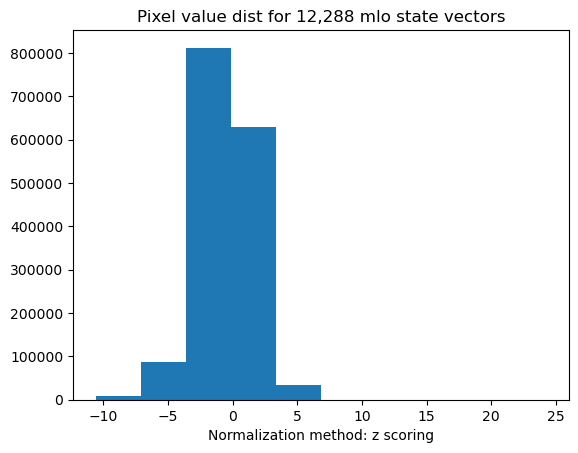

In [109]:
plt.hist(y.reshape(-1))
plt.title("Pixel value dist for 12,288 mlo state vectors")
plt.xlabel("Normalization method: z scoring")
plt.show()

In [102]:

from ipywidgets import interact, widgets

def variable_dist_viewer(y, cmap='viridis', dataset=dataloaders[1].dataset):
    # Define interactive plot function
    def plot_image(variable):
        plt.hist(y[:, variable].numpy())
        plt.title(f"Variable {dataset.mlo[variable].item()}")
        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = y.shape
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    
    # Display interactive plot
    interact(plot_image, variable=variable_slider)

# Example usage:
# images = np.random.rand(100, 128, 16, 24) # Replace with your actual data
variable_dist_viewer(y)

interactive(children=(IntSlider(value=0, description='Variable:', max=127), Output()), _dom_classes=('widget-i…

In [103]:
y[:,52].shape

torch.Size([12288])

In [104]:
gmm = GaussianMixture(n_components=2)



GaussianMixture(n_components=2)

In [136]:
def u_q_batch(x_1, x_2, mu, var, h):
    # x_1, x_2: shape [batch_size, feature_dim]
    # mu: shape [batch_size, feature_dim] or [feature_dim]
    # var: shape [batch_size, feature_dim] or [feature_dim] or scalar
    
    # Compute the score function (gradient of log density) of a single Gaussian
    score_x1 = (mu - x_1) / var 
    score_x2 = (mu - x_2) / var
    if h == float('inf'):
        return score_x1 * score_x2
    else:
        squared_diff = (x_1 - x_2) ** 2
        kernel = torch.exp(-squared_diff / (2 * h ** 2))
        
        return kernel * (
            score_x1 * score_x2 - 
            (score_x1 - score_x2) * (x_1 - x_2) / h ** 2 + 
            1 / h ** 2 - 
            squared_diff / h ** 4
        )

In [152]:
loss_fn(y.to(device), y_hat.to(device))

tensor(4.6360, device='cuda:0', grad_fn=<MseLossBackward0>)

In [153]:
distribution_loss(y_hat.to(device), y.to(device), n_samples=10)

tensor(0.3419, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)

In [111]:
n_samples = 3

ix, jx = torch.randint(0, bs, (n_samples,)), torch.randint(0, bs, (n_samples,))
mask = ix == jx
while mask.any():
    ix[mask] = torch.randint(0, bs, (mask.sum(),))
    jx[mask] = torch.randint(0, bs, (mask.sum(),))
    mask = ix == jx

ix, jx


(tensor([ 7, 31, 27]), tensor([17, 22,  2]))

In [135]:
zb.sum(axis=0)

tensor([[0.1003, 0.1040, 0.1001,  ..., 0.1061, 0.0964, 0.0963],
        [0.0979, 0.0977, 0.0995,  ..., 0.1119, 0.0943, 0.0925],
        [0.1056, 0.1210, 0.0948,  ..., 0.1036, 0.0941, 0.1071],
        ...,
        [0.1030, 0.0987, 0.1017,  ..., 0.1151, 0.0905, 0.0815],
        [0.0978, 0.0939, 0.1036,  ..., 0.1178, 0.0921, 0.0817],
        [0.0994, 0.0948, 0.1027,  ..., 0.1127, 0.0901, 0.0834]],
       device='cuda:0', dtype=torch.float64, grad_fn=<SumBackward1>)

In [117]:
means, weights, covariances, overall_mean, overall_std, h

(tensor([-0.4105], device='cuda:0', dtype=torch.float64),
 tensor([1.], device='cuda:0', dtype=torch.float64),
 tensor([4.4695], device='cuda:0', dtype=torch.float64),
 tensor(-0.4105, device='cuda:0', dtype=torch.float64),
 tensor(2.1141, device='cuda:0', dtype=torch.float64),
 6.342330694198608)

In [120]:
def u_q(x_1, x_2, mu, var, h):
    # Compute the score function (gradient of log density) of a single Gaussian
    score_x1 = (mu - x_1) / var
    score_x2 = (mu - x_2) / var

    # Compute kernel term
    if h == float('inf'):
        return score_x1 * score_x2
    else:
        kernel = torch.exp(-(x_1 - x_2) ** 2 / (2 * h ** 2))
        return kernel * (score_x1 * score_x2 - (score_x1 - score_x2) * (x_1 - x_2) / h ** 2 + 1 / h ** 2 - (x_1 - x_2) ** 2 / h ** 4)

In [68]:
def u_q(x_1, x_2, mu, var, pi, h):
    # Compute log probabilities and weights for GMM components
    log_probs = torch.log(pi) - 0.5 * torch.log(var) - (x_1 - mu) ** 2 / 2 / var
    log_weights1 = torch.log(x_1) - torch.log(var)
    log_weights2 = torch.log(mu) - torch.log(var)
    log_sum_weights1 = torch.logsumexp(log_probs + log_weights1, dim=1, keepdim=True)
    log_sum_weights2 = torch.logsumexp(log_probs + log_weights2, dim=1, keepdim=True)
    log_sum_probs = torch.logsumexp(log_probs, dim=1, keepdim=True)
    sq1 = torch.exp(log_sum_weights1 - log_sum_probs) - torch.exp(log_sum_weights2 - log_sum_probs)

    # Compute log probabilities and weights for the second input
    log_probs = (torch.log(pi) - 0.5 * torch.log(var)).unsqueeze(1) - (x_2 - mu.unsqueeze(1)) ** 2 / 2 / var.unsqueeze(1)
    log_weights1 = torch.log(x_2) - torch.log(var).unsqueeze(1)
    log_weights2 = (torch.log(mu) - torch.log(var)).unsqueeze(1)
    log_sum_weights1 = torch.logsumexp(log_probs + log_weights1, dim=0, keepdim=True)
    log_sum_weights2 = torch.logsumexp(log_probs + log_weights2, dim=0, keepdim=True)
    log_sum_probs = torch.logsumexp(log_probs, dim=0, keepdim=True)
    sq2 = torch.exp(log_sum_weights1 - log_sum_probs) - torch.exp(log_sum_weights2 - log_sum_probs)

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return sq1 * sq2
    else:
        return torch.exp(-(x_1 - x_2) ** 2 / 2 / (h ** 2)) * (
                    sq1 * sq2 - (sq1 - sq2) * (x_1 - x_2) / h ** 2 + 1 / h ** 2 - (x_1 - x_2) ** 2 / h ** 4)

In [105]:
u_q(y1, y2, means, covariances, h)

tensor([[0.0334, 0.0345, 0.0336,  ..., 0.0351, 0.0321, 0.0318],
        [0.0325, 0.0329, 0.0336,  ..., 0.0373, 0.0317, 0.0306],
        [0.0352, 0.0404, 0.0316,  ..., 0.0345, 0.0316, 0.0357],
        ...,
        [0.0345, 0.0328, 0.0338,  ..., 0.0384, 0.0304, 0.0273],
        [0.0326, 0.0313, 0.0346,  ..., 0.0392, 0.0306, 0.0272],
        [0.0331, 0.0315, 0.0343,  ..., 0.0376, 0.0300, 0.0278]],
       device='cuda:0', dtype=torch.float64, grad_fn=<MulBackward0>)

## Scratch

In [63]:
model, losses = vanilla_train(model, train_ds, loss_fn, tconfig)

Epoch [1/10], Train Loss: 0.0505, Test Loss: 0.0336
Epoch [2/10], Train Loss: 0.0204, Test Loss: 0.0393
Epoch [3/10], Train Loss: 0.0180, Test Loss: 0.0469
Epoch [4/10], Train Loss: 0.0170, Test Loss: 0.0483
Epoch [5/10], Train Loss: 0.0164, Test Loss: 0.0500
Saving Model
Epoch [6/10], Train Loss: 0.0160, Test Loss: 0.0531
Epoch [7/10], Train Loss: 0.0158, Test Loss: 0.0555
Epoch [8/10], Train Loss: 0.0155, Test Loss: 0.0577
Epoch [9/10], Train Loss: 0.0154, Test Loss: 0.0591
Epoch [10/10], Train Loss: 0.0152, Test Loss: 0.0607
Saving Model


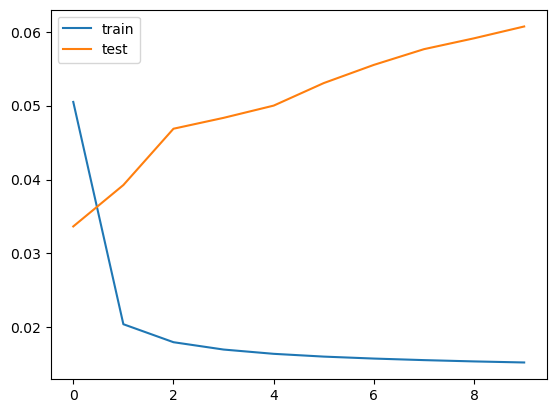

In [64]:
plt.plot(losses['train'], label='train')
plt.plot(losses['test'], label='test')
plt.legend()
plt.show()

## Diffusion Augmented training

In [33]:
exp_id = "full_dataset_testrun"
base_dir = os.path.join("experiments", exp_id)
run_id = "trial_1b"
tconfig, mconfig, dconfig = tru.load_config(run_id, exp_id)


TrainLoaderParams(batch_size=256, shuffle=True, num_workers=8, prefetch_factor=4, persistent_workers=True, multiprocessing_context='forkserver', pin_memory=True)

In [7]:
ddpm = tru.load_model_from_ckpt(f"{run_id}-ckpt.pt", mconfig, exp_id).to(device)
mconfig.scheduler_type = "ddim"
scheduler = data.load_scheduler(mconfig)
scheduler.set_timesteps(num_inference_steps=mconfig.scheduler_inference_steps)
ddpm.device

device(type='cuda', index=0)

In [8]:
scheduler.timesteps

tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [49]:
%%time
x, y = train_ds[0]

CPU times: user 505 ms, sys: 775 ms, total: 1.28 s
Wall time: 1.18 s


In [52]:
model = nn.Sequential(
    nn.Linear(in_features=124, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
).to(device)

In [14]:
y_hat = model(x.to(device))

In [15]:
def construct_image(ytensor):
    # more complex in actual setup
    return(torch.transpose(ytensor, 1, 2).reshape(-1, 128, 16, 24))

In [103]:
loss_fn = nn.MSELoss()
def image_loss(y, yhat, T: int, unet=ddpm, scheduler=scheduler):
    y, yhat = construct_image(y), construct_image(yhat)
    def encode(sample):
        eps = torch.randn(sample.shape, device=device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([T])) # noisy image
        return(xt)
    def decode(xt):
        for t in range(T, 0, -1):
            with torch.no_grad():
                eps_theta = unet(xt, t).sample
            xt = scheduler.step(eps_theta, t, xt).prev_sample
        return(xt)
    yhat = decode(encode(yhat))
    return(loss_fn(y, yhat))

In [54]:
image_loss(y.to(device), y_hat, 25)

tensor(1.4329, device='cuda:0', grad_fn=<MseLossBackward0>)

In [62]:
4204/256

16.421875

In [69]:
tconfig.num_epochs

20

In [72]:

len(test_ds)

8

In [80]:
%%time
c, d = train_ds[5]

CPU times: user 437 ms, sys: 1.85 ms, total: 438 ms
Wall time: 402 ms


In [81]:
%%time
loss_fn(model(a.to(device)), b.to(device))

CPU times: user 29.9 ms, sys: 0 ns, total: 29.9 ms
Wall time: 29.5 ms


tensor(0.9858, device='cuda:0', grad_fn=<MseLossBackward0>)

In [76]:
def evaluate_diff(model):
    loss = 0.0
    model.eval()
    with torch.no_grad():
        for idx in range(len(test_ds)):
            print(idx, end=" ")
            x, y = test_ds[idx]
            x, y = x.to(device), y.to(device)
            loss += loss_fn(model(x), y).item()
    return(loss / len(test_ds))

In [107]:
scheduler.timesteps

tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [121]:
def diffusion_train(model, dataset, loss_fn, tconfig):
    optimizer = torch.optim.Adam(model.parameters(), lr=tconfig.learning_rate, weight_decay=1e-4)
    losses = dict(train=[], diffusion=[], test=[])
    for epoch in range(1, tconfig.num_epochs+1):
        model.train()  # Set the model to training mode
        pixel_loss, img_loss = 0.0, 0.0
        for idx in range(len(dataset)):
            print(idx, end=" ")
            x, y = dataset[idx]
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(x)
            ploss = loss_fn(y, y_hat)
            iloss = image_loss(y, y_hat, T=25)
            (ploss + iloss).backward()
            optimizer.step()
            pixel_loss += ploss.item(); img_loss += iloss.item()
            losses['train'].append(ploss.item()); losses['diffusion'].append(iloss.item());
        # Print training progress
        #average_loss = running_loss / len(dataloader)
        #test_loss = evaluate(model).item()
        print(f'\nEpoch [{epoch}/{tconfig.num_epochs}], Pixel Loss: {pixel_loss/len(dataset):.4f}, Image Loss: {img_loss/len(dataset):.4f}')
        
        if(epoch % tconfig.batch_checkpoint_interval == 0):
            print("Saving Model")
            torch.save(model.state_dict(), tconfig.ckpt_id)

    return(model, losses)

In [116]:
model = nn.Sequential(
    nn.Linear(in_features=124, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
).to(device)

In [122]:
loss_fn(model(x.to(device)), y.to(device))

tensor(1.3941, device='cuda:0', grad_fn=<MseLossBackward0>)

In [123]:
x, y = train_ds[0]

In [127]:
model, losses = diffusion_train(model, train_ds, loss_fn, tconfig)

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [1/10], Pixel Loss: 1.0640, Image Loss: 1.0884
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [2/10], Pixel Loss: 1.0268, Image Loss: 1.0556
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [3/10], Pixel Loss: 0.9956, Image Loss: 1.0274
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [4/10], Pixel Loss: 0.9671, Image Loss: 1.0011
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [5/10], Pixel Loss: 0.9403, Image Loss: 0.9758
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [6/10], Pixel Loss: 0.9146, Image Loss: 0.9515
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [7/10], Pixel Loss: 0.8901, Image Loss: 0.9280
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [8/10], Pixel Loss: 0.8668, Image Loss: 0.9055
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [9/10], Pixel Loss: 0.8446, Image Loss: 0.8840
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [10/10], Pixel Loss: 0.8236, Image Loss: 0.8637


In [130]:
torch.save(model.state_dict(), "experiments/JointTraining/diffusion_train.pt")

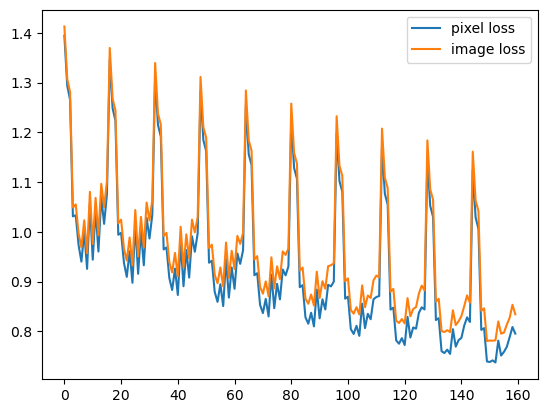

In [134]:
plt.plot(losses['train'], label='pixel loss')
plt.plot(losses['diffusion'], label='image loss')
plt.legend()
plt.show()

In [137]:
import json

In [139]:
with open("experiments/JointTraining/diffusion_train_losses.json", "w") as file:
    json.dump(losses, file)